# Near Field Projection Demo (Circle)

This notebook demonstrates how to compute the scattered field and use the projection operator to measure the field on a circle surrounding the perturbation.

In [12]:
import sys
import os
# Add project root to path
sys.path.append("..")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from inverse_scattering_jax.src.helmholtz import HelmholtzSolver, HelmholtzOperator, Domain
from inverse_scattering_jax.src.inverse_scattering import IncomingDirections, ForwardModel, get_projection_op
from inverse_scattering_jax.src.plot_utils import Plotting

jax.config.update("jax_enable_x64", True)

In [13]:
# Parameters
nx = 100
ny = 100
npml = 10
h = 0.1
omega = 10.0
sigma_max = 5.0
n_theta = 1

# Define Scatterer (Gaussian Perturbation)
x = jnp.arange(nx) * h
y = jnp.arange(ny) * h
X, Y = jnp.meshgrid(x, y)
cx, cy = nx * h / 2, ny * h / 2

def gaussian(x, y, x0, y0, sigma):
    return jnp.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

eta = 0.5 * gaussian(X, Y, cx, cy, 1.0)

# Remove PML region from perturbation for interior logic if needed
# But for simplicity, we pass interior eta to forward model
nxi = nx - 2 * npml
nyi = ny - 2 * npml
eta_interior = eta[npml:-npml, npml:-npml]

In [14]:
# Define Projection Operator: Circle surrounding the perturbation
radius = 3.0
n_circle_points = 100

theta_circle = jnp.linspace(0, 2 * jnp.pi, n_circle_points, endpoint=False)
circle_x = cx + radius * jnp.cos(theta_circle)
circle_y = cy + radius * jnp.sin(theta_circle)

points_query = jnp.stack([circle_x, circle_y], axis=1)

projection_op = get_projection_op(x, y, points_query)

# Setup Forward Model
domain = Domain(nx=nx, ny=ny, npml=npml, h=h)
op = HelmholtzOperator(domain=domain, omega=omega, sigma_max=sigma_max, mode='matrix')
solver = HelmholtzSolver(op=op)
inc = IncomingDirections(domain=domain, omega=omega, n_theta=n_theta)
fwd_model = ForwardModel(solver, inc, projection_op)

In [15]:
# Compute Forward
# ForwardModel expects eta interior (without PML)
u_scattered_projected = fwd_model.forward(eta_interior)

print("Scattered field shape (Observation Points, Sources):", u_scattered_projected.shape)

Scattered field shape (Observation Points, Sources): (100, 1)


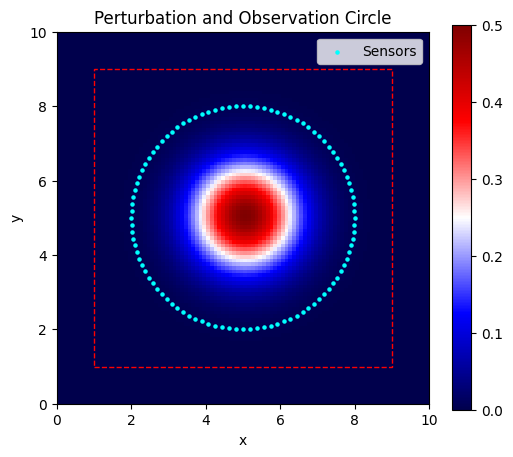

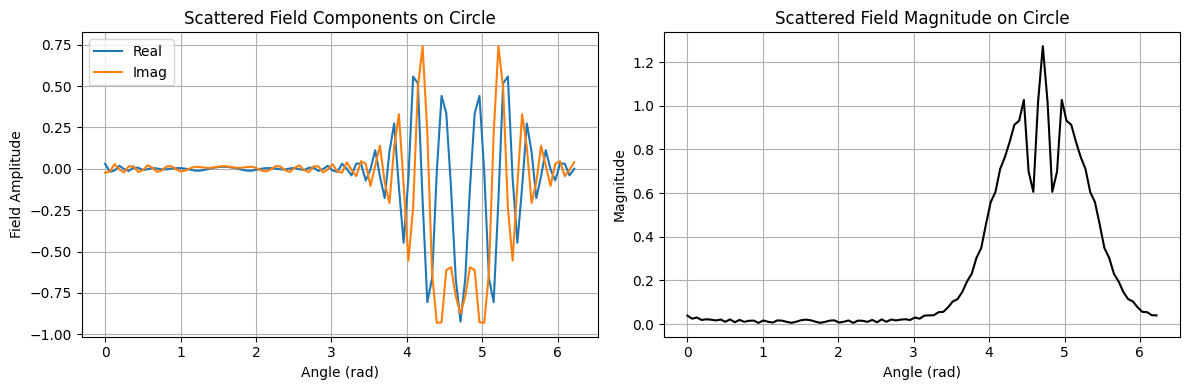

In [16]:
# Plotting
plotter = Plotting(nx, ny, h, npml, n_theta, sampling_points=len(points_query))

# Plot Perturbation with Circle locations
fig, ax = plt.subplots(figsize=(6, 5))
plotter.plot_perturbation(eta, title="Perturbation and Observation Circle", ax=ax)
ax.scatter(circle_x, circle_y, c='cyan', s=5, label='Sensors')
ax.legend()
plt.show()

# Plot Scattered Field on the Circle
u_circle = u_scattered_projected[:, 0] # First source

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Real and Imaginary parts vs Angle
ax1.plot(theta_circle, np.real(u_circle), label='Real')
ax1.plot(theta_circle, np.imag(u_circle), label='Imag')
ax1.set_xlabel("Angle (rad)")
ax1.set_ylabel("Field Amplitude")
ax1.set_title("Scattered Field Components on Circle")
ax1.legend()
ax1.grid(True)

# Absolute value (Polar Plot concept, but linear here for readability)
ax2.plot(theta_circle, np.abs(u_circle), 'k-', label='Amplitude')
ax2.set_xlabel("Angle (rad)")
ax2.set_ylabel("Magnitude")
ax2.set_title("Scattered Field Magnitude on Circle")
ax2.grid(True)

plt.tight_layout()
plt.show()